In [41]:
import math
import os
from pathlib import Path

import PIL
import matplotlib.pyplot as plt #3.10.8
import matplotlib.image as imread
import seaborn as sns #0.13.2
import numpy as np #2.4.4
import pandas as pd #3.0.2
from PIL import Image #12.1.1


In [42]:
# Config dataset01_split
TRAIN_PATH = Path('train')
TEST_PATH = Path('test')
LABELS_TRAIN_PATH = Path('labels', 'train_gabarito.csv')

Tamanho do dataset e distribuição de classes

In [43]:
files_train_gen = TRAIN_PATH.glob('*.*')
files_train_path_list = [file for file in files_train_gen]

files_test_gen = TEST_PATH.glob('*.*')
files_test_path_list = [file for file in files_test_gen]

print(f'Training size: {len(files_train_path_list)}')
print(f'Testing size: {len(files_test_path_list)}')

Training size: 800
Testing size: 200


In [44]:
labels_train_df = pd.read_csv(LABELS_TRAIN_PATH)
labels_train_df.head()


,Nome,Label
0,Good_data03_good (422).jpg,1
1,Bad_data01_bad (369).jpg,0
2,Good_data03_good (332).jpg,1
3,Bad_data01_bad (457).jpg,0
4,Good_data03_good (364).jpg,1


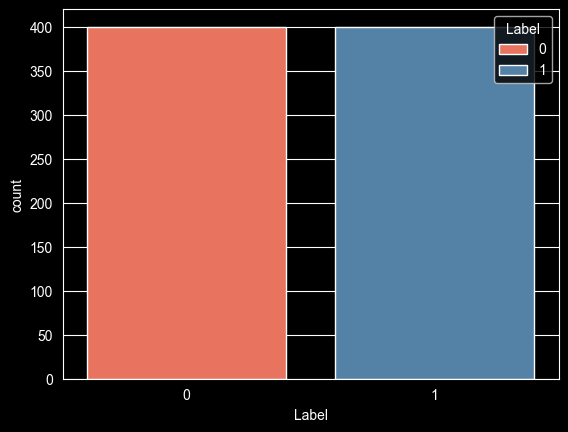

In [45]:
_ = sns.countplot(data=labels_train_df, x ='Label', hue='Label', palette={0: 'tomato', 1: 'steelblue'})
plt.show()

In [46]:
labels_train_df.value_counts(["Label"], normalize=True)

Label
1        0.5
0        0.5
Name: proportion, dtype: float64

Checks de sanidade

In [50]:
class SanityChecks:
    def __init__(self, path: Path) -> None:
        self.path = path
        self.files_list = self.__get_path_list()
        self.mode_types = []
        self.width = []
        self.height = []

    def __get_path_list(self) -> list:
        files_path_gen = self.path.glob('*.*')
        return [file for file in files_path_gen]

    def check_corruption(self) -> dict:
        error = []
        for file in self.files_list:
            try:
                img = Image.open(file)
                self.mode_types.append(img.mode)
                self.width.append(img.width)
                self.height.append(img.height)
            except:
                error.append(file)
        return {
            'qt_errors': len(error), 'files_erros': error}

    def check_typing(self) -> dict:
        print(self.files_list[0])
        ext = [str(file).split('.')[-1] for file in self.files_list]
        return {
            "ext": list(set(ext))
        }
    def check_mode(self) -> dict:
        return {
            'modes': list(set(self.mode_types))
        }

    def check_dimensions (self) -> dict:
        return {
            'width': list(set(self.width)),
            'height': list(set(self.height))
        }

In [53]:
sanity_checks = SanityChecks(TRAIN_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
train\Bad_data01_bad (1).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}


{'width': [517,
  518,
  520,
  1546,
  527,
  1040,
  1044,
  1556,
  1558,
  1563,
  540,
  1568,
  1578,
  1068,
  1071,
  1584,
  1586,
  1599,
  1600,
  1089,
  1099,
  1102,
  1105,
  1109,
  1118,
  1119,
  1125,
  1126,
  1153,
  1155,
  1162,
  1172,
  1175,
  1184,
  1186,
  1188,
  1189,
  1196,
  1198,
  1209,
  1212,
  1214,
  1218,
  1224,
  1230,
  1234,
  1236,
  1237,
  5339,
  1248,
  1249,
  738,
  1252,
  1253,
  5866,
  1259,
  1261,
  1267,
  1271,
  1273,
  1277,
  1280,
  1284,
  1289,
  1293,
  1296,
  1308,
  1317,
  1331,
  1333,
  1334,
  1335,
  1337,
  1338,
  1339,
  1341,
  1352,
  1355,
  1356,
  1357,
  1361,
  1364,
  1373,
  1376,
  1397,
  1399,
  1408,
  1413,
  1418,
  1421,
  1427,
  1428,
  1434,
  1441,
  1446,
  424,
  1453,
  942,
  437,
  1463,
  1467,
  1471,
  1474,
  965,
  1478,
  975,
  466,
  468,
  1494,
  1500,
  479,
  1505,
  487,
  492,
  1523,
  1532],
 'height': [1537,
  517,
  518,
  520,
  1547,
  1549,
  5136,
  1042,
  1561,

In [54]:
sanity_checks = SanityChecks(TEST_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
test\Bad_data01_bad (10).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}
{'width': [1280, 1153, 1408, 1155, 1284, 1413, 1546, 1162, 1421, 1040, 1296, 1427, 1428, 1556, 1172, 1175, 1558, 1308, 540, 1184, 1568, 1186, 1188, 1317, 1189, 1446, 1068, 1453, 1071, 1584, 1333, 1078, 1463, 1335, 1209, 1338, 1339, 1467, 1341, 1214, 1471, 1600, 1474, 1478, 1224, 1352, 1355, 1356, 1357, 1230, 1361, 1234, 1236, 1109, 1364, 1494, 1500, 1373, 1119, 1376, 1505, 738, 1248, 1249, 1253, 1259, 1267, 1523, 1397, 1399, 1271, 1532], 'height': [512, 1280, 1537, 1155, 1284, 1409, 1286, 1160, 1417, 1547, 1420, 1293, 1291, 1549, 1296, 1170, 1427, 1304, 1561, 1433, 539, 540, 1437, 1049, 1183, 1190, 1575, 1191, 1066, 1451, 1197, 1326, 1456, 1200, 1202, 1075, 1204, 1081, 1338, 1467, 1209, 1465, 1470, 1215, 1600, 1217, 1346, 1348, 1477, 1476, 1351, 1227, 1356, 1357, 1230, 1228, 1232, 1361, 1364, 1237, 1242, 1115, 1500, 737, 1251, 1254, 1388, 1389, 1390, 1266, 1399, 1274, 1150]}


In [ ]:
def plot_images()